In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

<Figure size 1000x600 with 0 Axes>

In [6]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/nav_history_cleaned.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [7]:
datasets = {
    "fund_master": fund_master,
    "nav_history": nav_history,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "performance": performance,
    "transactions": transactions,
    "holdings": holdings,
    "benchmark": benchmark
}

for name, df in datasets.items():
    print(name, df.shape)

fund_master (40, 15)
nav_history (46000, 3)
aum (90, 5)
sip (48, 6)
category (144, 3)
folio (21, 6)
performance (40, 19)
transactions (32778, 13)
holdings (322, 8)
benchmark (8050, 3)


In [ ]:
# Date column is convert into datetime 
nav_history['date'] = pd.to_datetime(nav_history['date'])

# Date wise NAV trend plot
fig = px.line(
    nav_history,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022–2026) for All Schemes'
)

fig.show()

In [9]:
nav_history['date'] = pd.to_datetime(nav_history['date'])

fig = px.line(
    nav_history,
    x='date',
    y='nav',
    color='amfi_code',
    title='Daily NAV Trend (2022–2026)'
)

# 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    opacity=0.15
)

# 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    annotation_text="2024 Market Correction",
    annotation_position="top right",
    opacity=0.15
)

fig.show()

In [10]:
### Finding 1

Daily NAV trends indicate strong growth during 2023, reflecting a broad market bull run. NAV movement became relatively volatile during 2024, indicating periods of market correction across multiple schemes.

SyntaxError: invalid syntax (1144539191.py, line 3)

In [ ]:
print(aum.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


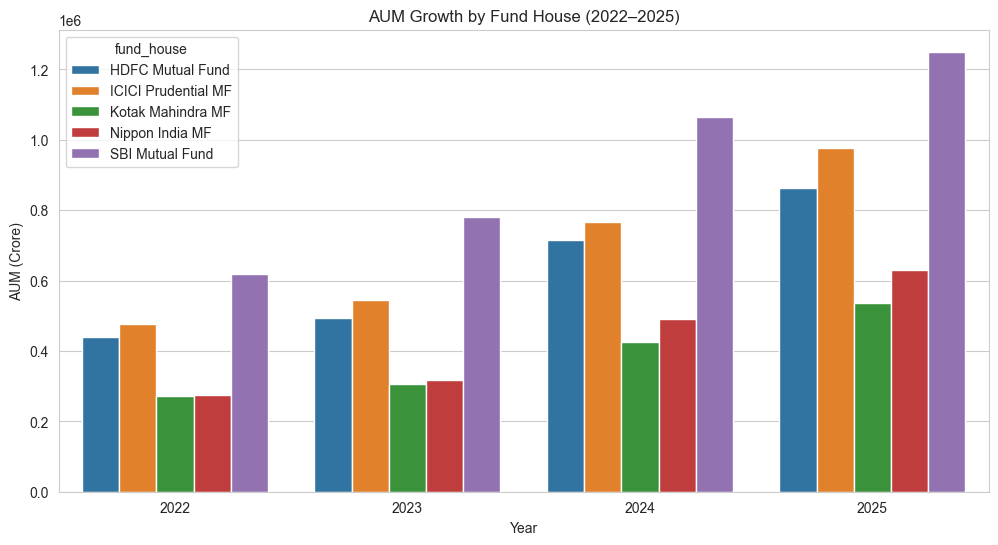

In [ ]:
#  Date column is convert into datetime 
aum['date'] = pd.to_datetime(aum['date'])

# to find year
aum['year'] = aum['date'].dt.year

# Yearly AUM by Fund House
aum_yearly = aum.groupby(['year', 'fund_house'])['aum_crore'].mean().reset_index()

# Top 5 fund houses only
top_funds = (
    aum.groupby('fund_house')['aum_crore']
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

aum_top = aum_yearly[aum_yearly['fund_house'].isin(top_funds)]

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_top,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
### Finding 2

SBI Mutual Fund consistently maintained the highest AUM across the observed period, demonstrating strong market leadership and investor confidence compared with other fund houses.|

SyntaxError: invalid syntax (2676769057.py, line 3)

In [ ]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [ ]:
# Month column is convert into datetime 
sip['month'] = pd.to_datetime(sip['month'])

# Plotly line chart
fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    title='Monthly SIP Inflows (Jan 2022 – Dec 2025)',
    markers=True
)

#  to find highest SIP inflow point 
max_row = sip.loc[sip['sip_inflow_crore'].idxmax()]

# to add annotation 
fig.add_annotation(
    x=max_row['month'],
    y=max_row['sip_inflow_crore'],
    text=f"All-Time High: ₹{max_row['sip_inflow_crore']:.0f} Cr",
    showarrow=True
)

fig.show()

In [ ]:
### Finding 3

Monthly SIP inflows showed a strong upward trend from 2022 to 2025, reflecting increasing retail investor participation. The highest inflow was recorded in late 2025, demonstrating sustained growth in systematic investing.

SyntaxError: invalid syntax (3899602315.py, line 3)

In [ ]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


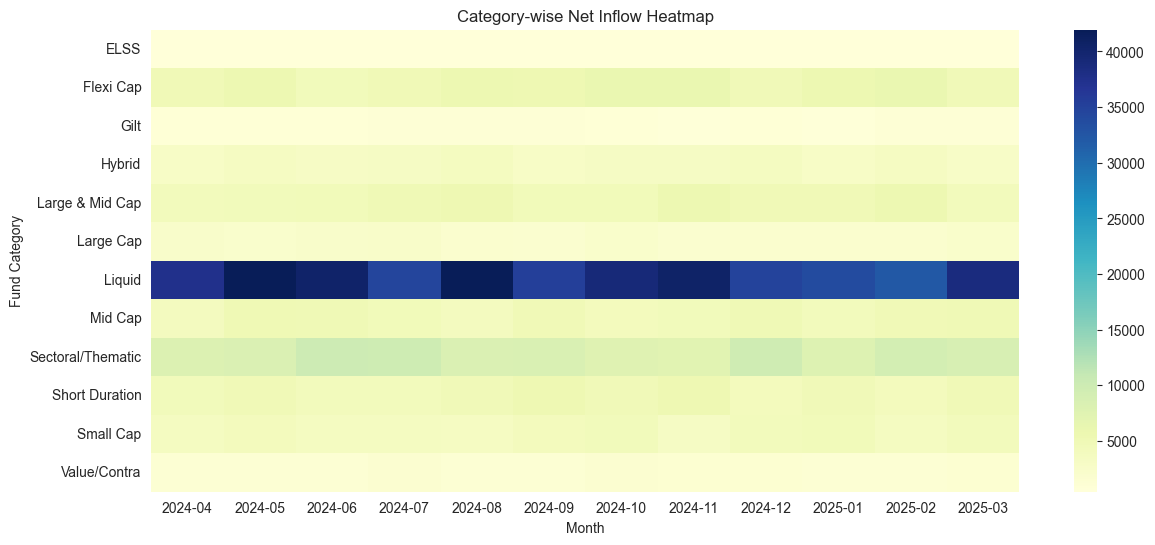

In [ ]:
# Month is convert into datetime 
category['month'] = pd.to_datetime(category['month'])

# Pivot table 
heatmap_data = category.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns=category['month'].dt.strftime('%Y-%m'),
    aggfunc='sum'
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    annot=False,
    cmap='YlGnBu'
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.show()

In [ ]:
### Finding 4

Net inflows varied significantly across fund categories. Certain categories consistently attracted higher investor inflows, while others experienced periods of lower participation depending on market conditions.

SyntaxError: invalid syntax (2396725497.py, line 3)

In [ ]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [ ]:
age_counts = transactions['age_group'].value_counts()

fig = px.pie(
    values=age_counts.values,
    names=age_counts.index,
    title="Investor Age Group Distribution"
)

fig.show()

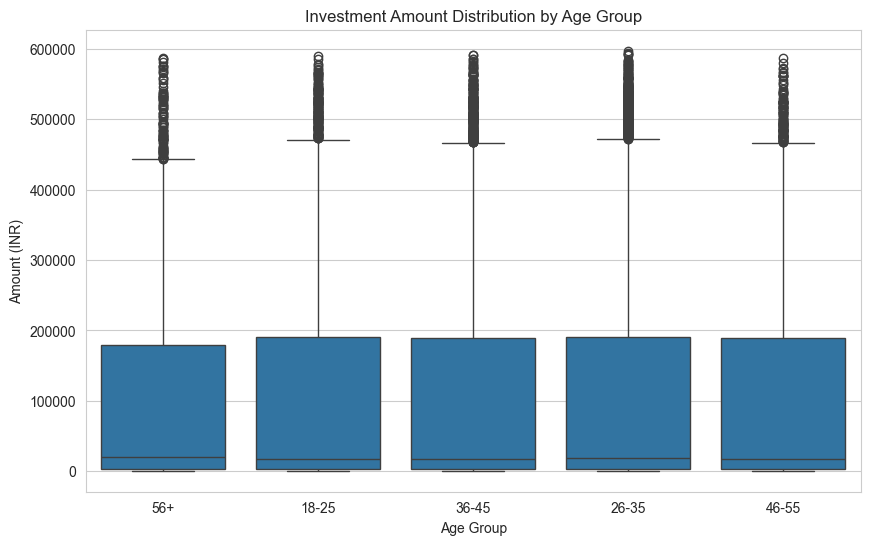

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x='age_group',
    y='amount_inr'
)

plt.title("Investment Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

In [ ]:
gender_counts = transactions['gender'].value_counts()

fig = px.pie(
    values=gender_counts.values,
    names=gender_counts.index,
    title="Gender Distribution of Investors"
)

fig.show()

In [ ]:
### Finding 5

Investor participation is distributed across multiple age groups, with certain age segments contributing a larger share of transactions. Investment amounts also vary significantly across age groups, indicating differences in investment capacity and financial goals.

SyntaxError: invalid syntax (3647592705.py, line 3)

In [ ]:
### Finding 6

The investor base includes participation from both genders, providing a diverse demographic profile. Gender-wise distribution highlights broad engagement in mutual fund investing across the population.

SyntaxError: invalid syntax (2152103596.py, line 3)

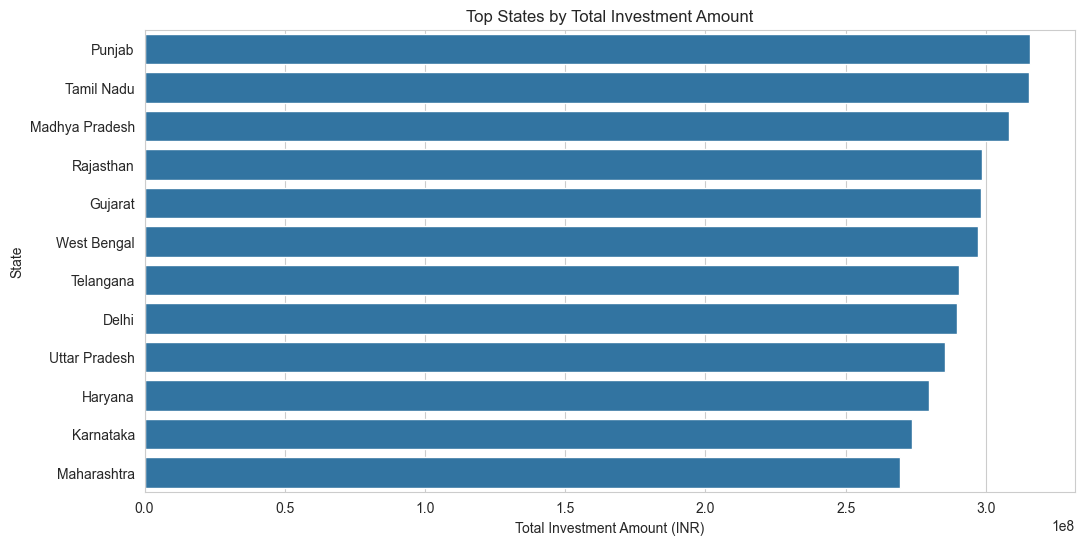

In [ ]:
state_data = (
    transactions.groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Top States by Total Investment Amount")
plt.xlabel("Total Investment Amount (INR)")
plt.ylabel("State")

plt.show()

In [ ]:
city_tier_counts = transactions['city_tier'].value_counts()

fig = px.pie(
    values=city_tier_counts.values,
    names=city_tier_counts.index,
    title="T30 vs B30 City Tier Distribution"
)

fig.show()

In [ ]:
### Finding 7

Investment activity is concentrated in a few leading states, indicating stronger mutual fund adoption and higher participation levels in those regions.

SyntaxError: invalid syntax (1845400437.py, line 3)

In [ ]:
### Finding 8

Both T30 and B30 cities contribute to mutual fund investments, demonstrating the growing penetration of investment products beyond major metropolitan areas.

SyntaxError: invalid syntax (3835638973.py, line 3)

In [ ]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [ ]:
# Month is convert into datetime 
folio['month'] = pd.to_datetime(folio['month'])

# Line chart
fig = px.line(
    folio,
    x='month',
    y='total_folios_crore',
    title='Mutual Fund Folio Growth (2022–2025)',
    markers=True
)

# First milestone
fig.add_annotation(
    x=folio.iloc[0]['month'],
    y=folio.iloc[0]['total_folios_crore'],
    text=f"Start: {folio.iloc[0]['total_folios_crore']} Cr",
    showarrow=True
)

# Last milestone
fig.add_annotation(
    x=folio.iloc[-1]['month'],
    y=folio.iloc[-1]['total_folios_crore'],
    text=f"End: {folio.iloc[-1]['total_folios_crore']} Cr",
    showarrow=True
)

fig.show()

In [ ]:
### Finding 9

Mutual fund folio counts increased substantially between 2022 and 2025, reflecting strong growth in investor participation and wider adoption of mutual fund products across the country.

SyntaxError: invalid syntax (642166284.py, line 3)

In [ ]:
print(nav_history.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [ ]:
# Top 10 AMFI codes
top_funds = nav_history['amfi_code'].unique()[:10]

nav_top10 = nav_history[
    nav_history['amfi_code'].isin(top_funds)
]

print(top_funds)

[100016 100025 100033 101206 101207 101208 102885 102886 102887 118632]


In [ ]:
pivot_nav = nav_top10.pivot(
    index='date',
    columns='amfi_code',
    values='nav'
)

pivot_nav.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [ ]:
returns = pivot_nav.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


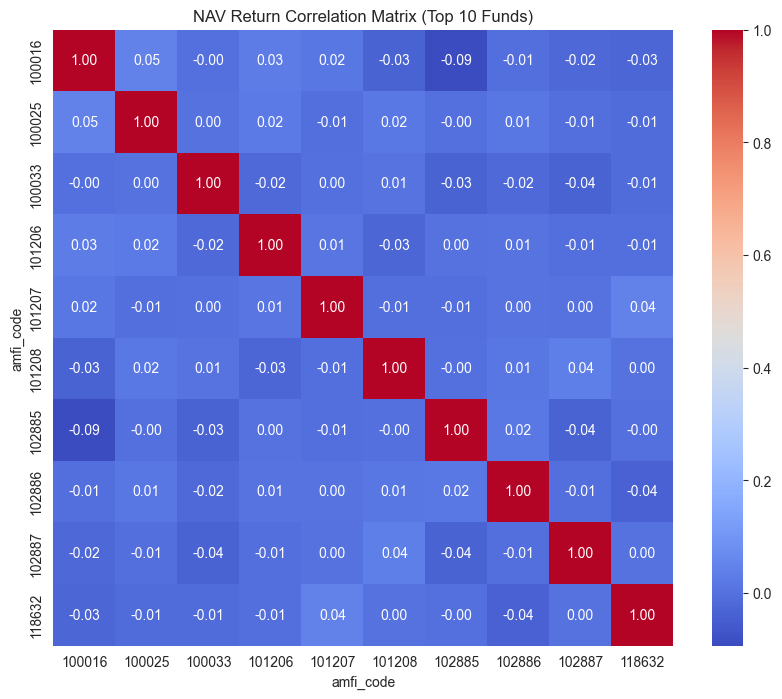

In [ ]:
corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("NAV Return Correlation Matrix (Top 10 Funds)")

plt.show()

In [ ]:
### Finding 10

Most mutual funds exhibit positive correlations in daily returns, indicating that they are influenced by common market movements. However, the degree of correlation varies across funds, reflecting differences in portfolio composition and investment strategies.

SyntaxError: invalid syntax (2343462094.py, line 3)

In [ ]:
print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [ ]:
sector_data = (
    holdings.groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_data.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

In [ ]:
fig = px.pie(
    values=sector_data.values,
    names=sector_data.index,
    title="Sector Allocation Across Equity Funds",
    hole=0.5
)

fig.show()

In [ ]:
### Finding 11

Portfolio allocations are concentrated in a few major sectors, indicating sector preferences among mutual fund managers. Sector exposure patterns highlight the dominant industries driving portfolio performance.

SyntaxError: invalid syntax (3149093389.py, line 3)

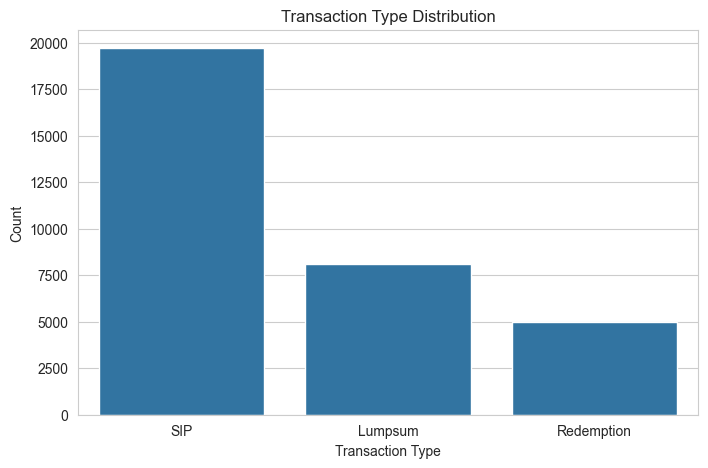

<Figure size 640x480 with 0 Axes>

In [14]:
trans_counts = transactions['transaction_type'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=trans_counts.index,
    y=trans_counts.values
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()
plt.savefig("../reports/chart_name.png", bbox_inches="tight")

In [ ]:
### Finding 12

SIP transactions constitute a significant share of total transactions, indicating investor preference for systematic and disciplined investing.

SyntaxError: invalid syntax (480878616.py, line 3)

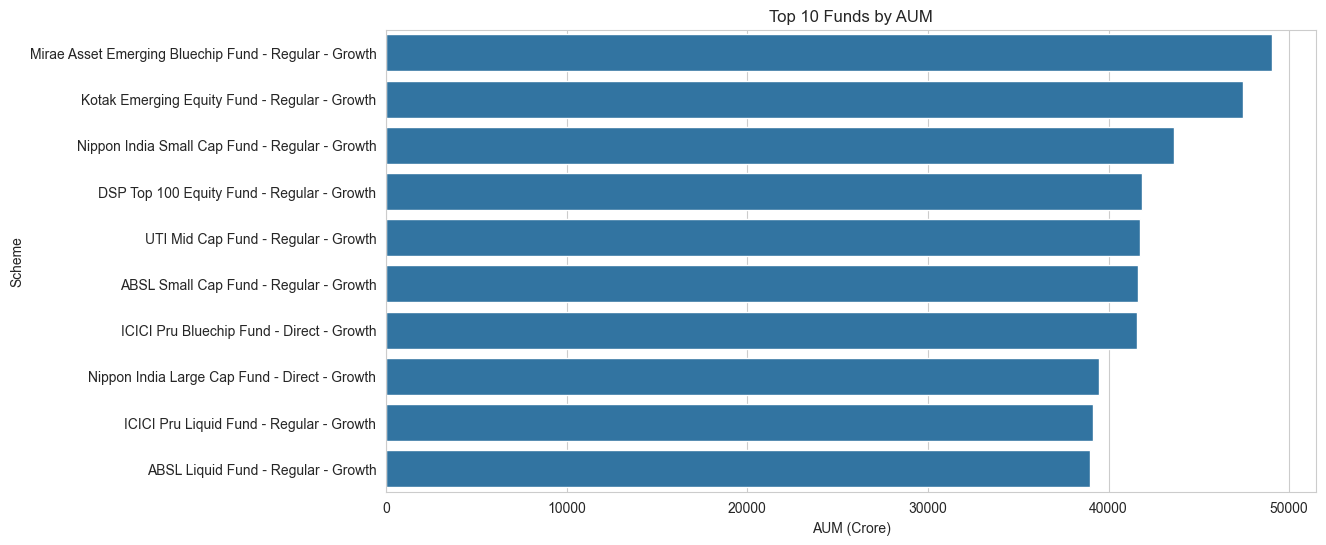

<Figure size 640x480 with 0 Axes>

In [13]:
top10_funds = performance.sort_values(
    by='aum_crore',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_funds,
    x='aum_crore',
    y='scheme_name'
)

plt.title("Top 10 Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Scheme")

plt.show()
plt.savefig("../reports/chart_name.png", bbox_inches="tight")

In [ ]:
### Finding 14

A small number of schemes account for a substantial share of total assets under management, indicating concentration among leading funds.

SyntaxError: invalid syntax (4242890940.py, line 3)

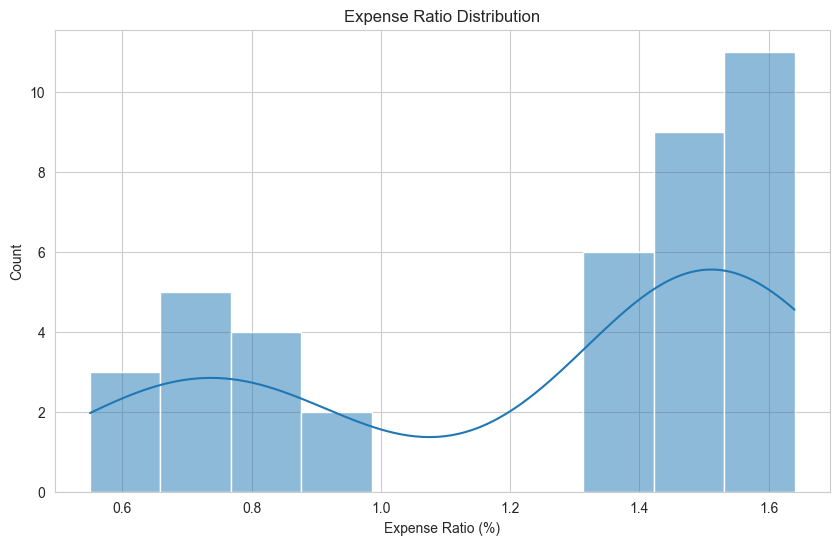

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.histplot(
    performance['expense_ratio_pct'],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")

plt.show()
plt.savefig("../reports/chart_name.png", bbox_inches="tight")


In [ ]:
### Finding 15

Most schemes maintain expense ratios within a moderate range, suggesting competitive cost structures across mutual fund offerings.

SyntaxError: invalid syntax (468221896.py, line 3)